In [1]:
import torch
import torch.nn as nn
import torch_pruning as tp
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torch.nn.utils.prune as prune
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
import numpy as np
import random
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

### This code uses the Imagenette2 dataset. The link to download it:
https://github.com/fastai/imagenette 

## Data Preparation 

In [2]:
class_mapping = {
    'n01440764': { 1 : 'tench'},
    'n02102040': { 2 : 'English_springer'},
    'n02979186': { 3 : 'cassette_player'},
    'n03000684': { 4 : 'chain saw'},
    'n03028079': { 5 : 'church'},
    'n03394916': { 6 : 'French horn'},
    'n03417042': { 7 : 'garbage truck'},
    'n03425413': { 8 : 'gas pump'},
    'n03445777': { 9 : 'golf ball'},
    'n03888257': { 10 : 'parachute'}
}

class_names = [list(v.values())[0] for v in class_mapping.values()]

train_dir = "./imagenette2/train"
val_dir = "./imagenette2/val"

In [3]:
def create_df(dataset_path): 
    data = []

    for class_folder in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_folder)

        if os.path.isdir(class_path) and class_folder in class_mapping:
            class_id, class_name = list(class_mapping[class_folder].items())[0]

            for img_file in os.listdir(class_path):
                img_path = os.path.join(class_path, img_file)

                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                except:
                     print('Unreadable file') 

                data.append([img_path, class_name, width, height, class_id])

    df = pd.DataFrame(data, columns=["image_path", "class_name", "width", "height", "class_id"])
    
    return df

train_df = create_df(train_dir)
val_df = create_df(val_dir)

## Augmentation

In [4]:
transform_train = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


transform_val = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

## Loading the dataset

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
class MAINDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        self.df["class_id"] = self.df["class_id"] - self.df["class_id"].min()  

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]

        image = Image.open(img_path).convert("RGB")

        label = int(self.df.iloc[idx]["class_id"])

        if self.transform:
            image = self.transform(image)

        return image, label
    
train_dataset = MAINDataset(train_df, transform=transform_train)
val_dataset = MAINDataset(val_df, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## Preparating the model and additional classes

In [7]:
class CustomDropout(nn.Module):
    def __init__(self, p=0.5):
        super(CustomDropout, self).__init__()
        self.default_p = p

    def forward(self, x, seed=None, p=None):
        dropout_p = self.default_p if p is None else p
        if seed is not None:
            torch.manual_seed(seed)
        if self.training:
            batch_size, output_nb_neurons = x.size()
            mask = (torch.rand(1, output_nb_neurons) > dropout_p).float().to(x.device)
            x = x * mask
            return x / (1 - dropout_p)
        else:
            return x

In [8]:
class SpatialDropout(nn.Module):
    def __init__(self, p=0.5):
        super(SpatialDropout, self).__init__()
        self.default_p = p

    def forward(self, x, seed=None, p=None):
        dropout_p = self.default_p if p is None else p
        if seed is not None:
            torch.manual_seed(seed)
        if self.training:
            batch_size, channels, height, width = x.size()
            mask = (torch.rand(1, channels, 1, 1) > dropout_p).float().to(x.device)
            x = x * mask
            return x / (1 - dropout_p)
        else:
            return x

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.spatial_dropout1 = SpatialDropout(p=0.5)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.spatial_dropout2 = SpatialDropout(p=0.5)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.spatial_dropout3 = SpatialDropout(p=0.5)
        self.fc1 = nn.Linear(256 * 16 * 16, 512)
        self.dropout = CustomDropout(p=0.5)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x, seed=None, dropout_p=None):
        x = F.relu(self.conv1(x))
        x = self.spatial_dropout1(x, seed=seed, p=dropout_p)
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = self.spatial_dropout2(x, seed=seed, p=dropout_p)
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = self.spatial_dropout3(x, seed=seed, p=dropout_p)
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x, seed=seed, p=dropout_p)
        x = self.fc2(x)
        return x

In [10]:
model_additional = SimpleCNN().to(device)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_additional.parameters(), lr=0.0001,  weight_decay=1e-4)

## Training and Validation functions
### With Seed Pool

In [12]:
def train_with_seed_pool(model, train_loader, criterion, optimizer, device, seed_pool, dropout_p):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_loader_tqdm = tqdm(train_loader, desc="Training (Seed Pool)")

    for images, labels in train_loader_tqdm:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        seed = random.choice(seed_pool) 
        outputs = model(images, seed=seed, dropout_p=dropout_p)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_loader_tqdm.set_postfix(loss=f"{running_loss / total:.4f}")

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    return train_loss, train_acc


In [13]:
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    val_loader_tqdm = tqdm(val_loader, desc="Validation")

    with torch.no_grad():
        for images, labels in val_loader_tqdm:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            val_loader_tqdm.set_postfix(loss=f"{running_loss / total:.4f}")

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total
    return val_loss, val_acc

In [15]:
def train_model_seed_pool(model, train_loader, val_loader, criterion, optimizer,
                          seed_pool, dropout_p, num_epochs, patience=5,
                          acc_gap_threshold=20.0, acc_gap_patience=3):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    epochs_overfit_gap = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} ----------------------------")

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        train_loader_tqdm = tqdm(train_loader, desc=f"Training (epoch {epoch+1})")

        for images, labels in train_loader_tqdm:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            seed = random.choice(seed_pool)
            outputs = model(images, seed=seed, dropout_p=dropout_p)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_loader_tqdm.set_postfix(loss=f"{running_loss / total:.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'initial_model_for_second_experiment.pth')
            print("Saved new best model!")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        acc_gap = train_acc - val_acc
        if acc_gap > acc_gap_threshold:
            epochs_overfit_gap += 1
            print(f"⚠️ Overfitting suspected: train_acc - val_acc = {acc_gap:.2f}% "
                  f"({epochs_overfit_gap}/{acc_gap_patience} epoch(s))")
        else:
            epochs_overfit_gap = 0

        if epochs_overfit_gap >= acc_gap_patience:
            print("Early stopping triggered due to consistent accuracy gap (overfitting).")
            break

        if epochs_no_improve >= patience:
            print("Early stopping triggered due to no val_loss improvement.")
            break

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies


### Model training

In [16]:
seed_pool = list(range(10))  
dropout_p = 0.5 

train_losses, val_losses, train_accuracies, val_accuracies = train_model_seed_pool( model= model_additional, train_loader=train_loader,
    val_loader=val_loader, criterion=criterion, optimizer=optimizer, seed_pool=seed_pool, dropout_p=dropout_p, num_epochs=25,
    patience=5
)


Epoch 1/25 ----------------------------


Validation: 100%|██████████| 62/62 [00:29<00:00,  2.09it/s, loss=0.0320]


Saved new best model!
Train Loss: 2.1625, Acc: 22.36% | Val Loss: 2.0232, Acc: 30.70%

Epoch 2/25 ----------------------------


Validation: 100%|██████████| 62/62 [00:30<00:00,  2.05it/s, loss=0.0300]


Saved new best model!
Train Loss: 1.8928, Acc: 34.23% | Val Loss: 1.9012, Acc: 39.82%

Epoch 3/25 ----------------------------


...

No improvement for 3 epoch(s).
Train Loss: 0.6783, Acc: 77.82% | Val Loss: 1.2546, Acc: 59.87%

Epoch 22/25 ----------------------------


Validation: 100%|██████████| 62/62 [00:35<00:00,  1.73it/s, loss=0.0196]


No improvement for 4 epoch(s).
Train Loss: 0.6461, Acc: 79.04% | Val Loss: 1.2404, Acc: 60.54%

Epoch 23/25 ----------------------------


Validation: 100%|██████████| 62/62 [00:35<00:00,  1.75it/s, loss=0.0195]

No improvement for 5 epoch(s).
Early stopping triggered due to no val_loss improvement.


# Experiment 1.B: Comparison Of Dropout-based vs. L2-Norm Pruning (With Control Mask Pool)

### Dropout-based Pruning part

In [14]:
def generate_dropout_mask_for_pruning(module, dropout_rate, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    if isinstance(module, nn.Linear):
        output_nb_neurons, _ = module.weight.size()
        mask = (torch.rand(1, output_nb_neurons) > dropout_rate).float()
        mask /= (1 - dropout_rate)  
    elif isinstance(module, nn.Conv2d):
        channels_output, _, _, _ = module.weight.size()
        mask = (torch.rand(1, channels_output, 1, 1) > dropout_rate).float()
        mask /= (1 - dropout_rate)  
    else:
        raise ValueError("Unknown dropout layer type")   
    return mask

In [15]:
def prune_model_based_on_dropout(model, dropout_rate, seed=None):
    mask_list = []
    for name, module in model.named_children():    
        if isinstance(module, nn.Linear):  

            mask = generate_dropout_mask_for_pruning(module, dropout_rate, seed)
            mask_list.append(torch.flatten(mask))
        
        elif isinstance(module, nn.Conv2d): 
            mask = generate_dropout_mask_for_pruning(module, dropout_rate, seed)
            mask_list.append(torch.flatten(mask))
            
        elif isinstance(module, CustomDropout):  
            pass
        
        elif isinstance(module, SpatialDropout):
            pass
        
        else: 
            pass
            
    example_inputs = torch.randn(1, 3, 128, 128).to(next(model.parameters()).device)
    model(example_inputs)
    
    DG = tp.DependencyGraph().build_dependency(model, example_inputs=example_inputs)
    
    mask_index = 0
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d):  
            mask = mask_list[mask_index]
            mask_index += 1
            prune_indices = np.where(mask == 0)[0]
            
            group = DG.get_pruning_group(module, tp.prune_conv_out_channels, prune_indices)

            group.prune()
            
            scaling_factor = 1 / (1 - dropout_rate)
            with torch.no_grad():
                module.weight.data *= scaling_factor
                if module.bias is not None:
                    module.bias.data *= scaling_factor

            
        if isinstance(module, nn.Linear) and not name == "fc2":  
            mask = mask_list[mask_index]
            mask_index += 1
            prune_indices = np.where(mask == 0)[0]

            group = DG.get_pruning_group(module, tp.prune_linear_out_channels, prune_indices)

            group.prune()
            
            scaling_factor = 1 / (1 - dropout_rate)
            with torch.no_grad():
                module.weight.data *= scaling_factor
                if module.bias is not None:
                    module.bias.data *= scaling_factor
    print("Model pruned.")
    return model

In [16]:
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

In [17]:
for dropout_rate in dropout_rates:
    print(f"\n=== Pruning with dropout_rate = {dropout_rate} ===")
    special_seed = 8
    exp_model = SimpleCNN().to(device)
    exp_model.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))

    pruned_model = prune_model_based_on_dropout(exp_model, dropout_rate, seed=special_seed)

    total_params = sum(p.numel() for p in pruned_model.parameters())
    trainable_params = sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)

    pruned_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = pruned_model(inputs, seed=special_seed, dropout_p=0.0) 
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    results.append({
        'dropout_rate': dropout_rate,
        'accuracy': accuracy,
        'total_params': total_params,
        'trainable_params': trainable_params
    })

df_DROPOUT_seed8 = pd.DataFrame(results)

df_DROPOUT_seed8['sparsity_%'] = 100 * (1 - df_DROPOUT_seed8['trainable_params'] / df_DROPOUT_seed8['trainable_params'].iloc[0])


=== Pruning with dropout_rate = 0.0 ===
Model pruned.

=== Pruning with dropout_rate = 0.1 ===
Model pruned.

=== Pruning with dropout_rate = 0.2 ===
Model pruned.

=== Pruning with dropout_rate = 0.3 ===
Model pruned.

=== Pruning with dropout_rate = 0.4 ===
Model pruned.

=== Pruning with dropout_rate = 0.5 ===
Model pruned.

=== Pruning with dropout_rate = 0.6 ===
Model pruned.

=== Pruning with dropout_rate = 0.7 ===
Model pruned.

=== Pruning with dropout_rate = 0.8 ===
Model pruned.

=== Pruning with dropout_rate = 0.9 ===
Model pruned.


In [34]:
print(df_DROPOUT_seed8[df_DROPOUT_seed8.duplicated(subset='dropout_rate')])

Empty DataFrame
Columns: [dropout_rate, accuracy, total_params, trainable_params, sparsity_%]
Index: []


In [18]:
df_DROPOUT_seed8 = df_DROPOUT_seed8.drop('total_params', axis=1)
df_DROPOUT_seed8

,dropout_rate,accuracy,trainable_params,sparsity_%
0,0.0,63.821656,33930890,0.000000
1,0.1,60.917197,27328902,19.457161
2,0.2,56.101911,21585496,36.383938
3,0.3,54.955414,17191829,49.332809
4,0.4,58.980892,12679956,62.630052
5,0.5,63.821656,7738751,77.192608
6,0.6,44.815287,4477673,86.803550
7,0.7,35.388535,2574198,92.413409
8,0.8,25.019108,1320224,96.109079
9,0.9,13.121019,329940,99.027612


### L2-Norm Pruning part

In [19]:
def l2_structured_prune_model(model, pruning_ratio, input_size=(1, 3, 128, 128), skip_last_linear=True):
    example_inputs = torch.randn(*input_size).to(next(model.parameters()).device)
    model(example_inputs)
    DG = tp.DependencyGraph().build_dependency(model, example_inputs=example_inputs)

    pruning_results = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weight_copy = module.weight.detach().abs().pow(2).sum(dim=(1, 2, 3))
            num_filters = module.out_channels
            num_prune = int(pruning_ratio * num_filters)

            if num_prune == 0 or num_filters <= 1:
                print(f"Skipped pruning {name} (too small or ratio too low)")
                pruning_results.append({
                    'Layer': name,
                    'Type': 'Conv2d',
                    'Original Units': num_filters,
                    'Pruned Units': 0,
                    'Pruned %': 0.0
                })
                continue

            prune_indices = weight_copy.argsort()[:num_prune].tolist()
            group = DG.get_pruning_group(module, tp.prune_conv_out_channels, prune_indices)
            group.prune()
            pruned_percent = 100.0 * num_prune / num_filters
            print(f"Pruned {num_prune}/{num_filters} filters ({pruned_percent:.2f}%) in {name}")

            pruning_results.append({
                'Layer': name,
                'Type': 'Conv2d',
                'Original Units': num_filters,
                'Pruned Units': num_prune,
                'Pruned %': pruned_percent
            })

        elif isinstance(module, nn.Linear) and module.out_features > 1:
            if skip_last_linear:
                if name == 'fc2':
                    print(f"Skipped pruning {name} (last output layer)")
                    pruning_results.append({
                        'Layer': name,
                        'Type': 'Linear',
                        'Original Units': module.out_features,
                        'Pruned Units': 0,
                        'Pruned %': 0.0
                    })
                    continue

            weight_copy = module.weight.detach().abs().pow(2).sum(dim=1)
            num_units = module.out_features
            num_prune = int(pruning_ratio * num_units)

            if num_prune == 0:
                print(f"Skipped pruning {name} (ratio too low)")
                pruning_results.append({
                    'Layer': name,
                    'Type': 'Linear',
                    'Original Units': num_units,
                    'Pruned Units': 0,
                    'Pruned %': 0.0
                })
                continue

            prune_indices = weight_copy.argsort()[:num_prune].tolist()
            group = DG.get_pruning_group(module, tp.prune_linear_out_channels, prune_indices)
            group.prune()
            pruned_percent = 100.0 * num_prune / num_units
            print(f"Pruned {num_prune}/{num_units} units ({pruned_percent:.2f}%) in {name}")

            pruning_results.append({
                'Layer': name,
                'Type': 'Linear',
                'Original Units': num_units,
                'Pruned Units': num_prune,
                'Pruned %': pruned_percent
            })

    pruning_df = pd.DataFrame(pruning_results)
    print("Pruning completed.")
    return model, pruning_df

In [20]:
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results_l2_structured = []

model_additional = SimpleCNN().to(device)
model_additional.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))
total_params_before_pruning = sum(p.numel() for p in model_additional.parameters() if p.requires_grad)

In [21]:
for rate in dropout_rates:
    print(f"\n=== L2 Structured Pruning for dropout_rate = {rate} ===")
    pruning_ratio = rate  

    model = SimpleCNN().to(device)
    model.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))
    model.eval()

    model, pruning_df = l2_structured_prune_model(model, pruning_ratio)

    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100.0 * correct / total

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pruned_percent = 100 * (1 - trainable_params / total_params_before_pruning)

    result = {
        'dropout_rate_for_pruning': rate,
        'accuracy': accuracy,
        'trainable_params': trainable_params,
        'sparsity_%': pruned_percent,
        'pruning_df': pruning_df
    }
    results_l2_structured.append(result)


=== L2 Structured Pruning for dropout_rate = 0.0 ===
Skipped pruning conv1 (too small or ratio too low)
Skipped pruning conv2 (too small or ratio too low)
Skipped pruning conv3 (too small or ratio too low)
Skipped pruning fc1 (ratio too low)
Skipped pruning fc2 (last output layer)
Pruning completed.

=== L2 Structured Pruning for dropout_rate = 0.1 ===
Pruned 6/64 filters (9.38%) in conv1
Pruned 12/128 filters (9.38%) in conv2
Pruned 25/256 filters (9.77%) in conv3
Pruned 51/512 units (9.96%) in fc1
Skipped pruning fc2 (last output layer)
Pruning completed.

=== L2 Structured Pruning for dropout_rate = 0.2 ===
Pruned 12/64 filters (18.75%) in conv1
Pruned 25/128 filters (19.53%) in conv2
Pruned 51/256 filters (19.92%) in conv3
Pruned 102/512 units (19.92%) in fc1
Skipped pruning fc2 (last output layer)
Pruning completed.

=== L2 Structured Pruning for dropout_rate = 0.3 ===
Pruned 19/64 filters (29.69%) in conv1
Pruned 38/128 filters (29.69%) in conv2
Pruned 76/256 filters (29.69%) in

In [23]:
records = []
for res in results_l2_structured:
    records.append({
        'dropout_rate_for_pruning': res['dropout_rate_for_pruning'],
        'accuracy': res['accuracy'],
        'trainable_params': res['trainable_params'],
        'sparsity_%': res['sparsity_%']
    })

df_L2_structured_overall = pd.DataFrame(records)

In [24]:
df_L2_structured_overall

,dropout_rate_for_pruning,accuracy,trainable_params,sparsity_%
0,0.0,63.821656,33930890,0.000000
1,0.1,61.910828,27570464,18.745238
2,0.2,60.101911,21761323,35.865747
3,0.3,58.675159,16730459,50.692543
4,0.4,51.668790,12281062,63.805659
5,0.5,51.694268,8484682,74.994225
6,0.6,48.891720,5468960,83.882061
7,0.7,40.738854,3072075,90.946082
8,0.8,28.942675,1387931,95.909536
9,0.9,14.242038,350790,98.966163


## Comparison of Two Methods

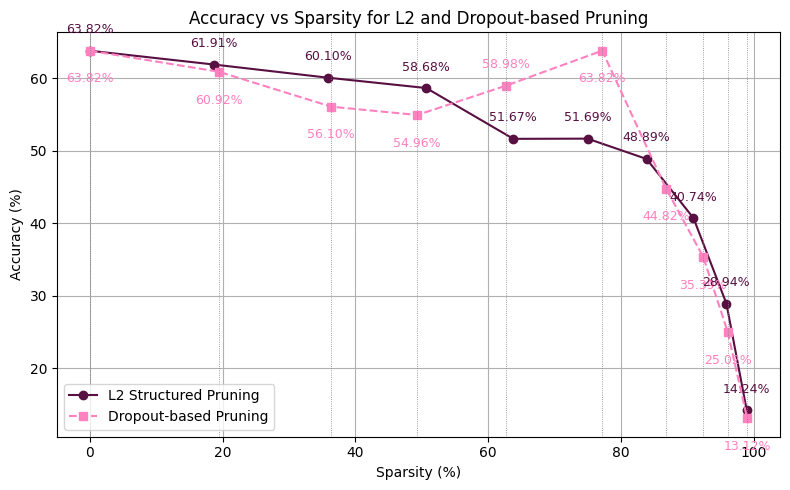

In [25]:
palette = ['#580F41', '#FF81C0']
plt.figure(figsize=(8, 5))

plt.plot(
    df_L2_structured_overall['sparsity_%'],
    df_L2_structured_overall['accuracy'],
    marker='o',
    linestyle='-',
    color=palette[0],
    label='L2 Structured Pruning'
)

plt.plot(
    df_DROPOUT_seed8['sparsity_%'],
    df_DROPOUT_seed8['accuracy'],
    marker='s',
    linestyle='--',
    color=palette[1],
    label='Dropout-based Pruning'
)

for i in range(len(df_DROPOUT_seed8)):
    x = df_DROPOUT_seed8['sparsity_%'].iloc[i]
    y = df_DROPOUT_seed8['accuracy'].iloc[i]
    plt.axvline(x=x, color='gray', linestyle=':', linewidth=0.6)
    
    if i == 4:
        plt.text(x, y + 2, f"{y:.2f}%", color=palette[1], ha='center', va='bottom', fontsize=9)
    else:
        plt.text(x, y - 3, f"{y:.2f}%", color=palette[1], ha='center', va='top', fontsize=9)

for i in range(len(df_L2_structured_overall)):
    x = df_L2_structured_overall['sparsity_%'].iloc[i]
    y = df_L2_structured_overall['accuracy'].iloc[i]
    plt.text(x, y + 2, f"{y:.2f}%", color=palette[0], ha='center', va='bottom', fontsize=9)

plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Sparsity for L2 and Dropout-based Pruning')
plt.legend()
plt.grid(True)
plt.savefig("code_fotos/comparing_dropout_l2_with_seed.pdf", format='pdf')
plt.tight_layout()
plt.show()


## Fine-Tuning After Pruning: Enhancement of Model Performance
### dropout = 0.5 

In [26]:
def evaluate_model_accuracy(model, val_loader, device, seed=None, dropout_p=0.0):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images, seed=seed, dropout_p=dropout_p) if seed is not None else model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    print(f"Accuracy of pruned model: {accuracy:.2f}%")
    return accuracy

In [27]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if trainable_params == 0:
        print("Warning: No trainable parameters!")
        return

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs} ----------------------------")
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        train_loader_tqdm = tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False)

        for images, labels in train_loader_tqdm:
            images, labels = images.to(next(model.parameters()).device), labels.to(next(model.parameters()).device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            grads_status = []
            for name, param in model.named_parameters():
                if param.requires_grad:
                    grads_status.append(f"{name}: {'Correct' if param.grad is not None else 'Incorrect'}")
            train_loader_tqdm.set_postfix({
                "loss": f"{loss.item():.4f}",
                "grads": ", ".join(grads_status[:3]) + (" ..." if len(grads_status) > 3 else "")  
            })

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_loader_tqdm = tqdm(val_loader, desc=f"Validation Epoch {epoch+1}", leave=False)

        with torch.no_grad():
            for images, labels in val_loader_tqdm:
                images, labels = images.to(next(model.parameters()).device), labels.to(next(model.parameters()).device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_loader_tqdm.set_postfix({
                    "val_loss": f"{loss.item():.4f}"
                })

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if scheduler:
            scheduler.step(val_loss)

In [28]:
def fine_tune_pruned_model(model, train_loader, val_loader, device, num_epochs, lr, scheduler_patience=5, use_scheduler=True):
    model.to(device)
    
    for _, param in model.named_parameters():
        param.requires_grad = True  

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=scheduler_patience
        )
    
    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs, scheduler=scheduler)
    
    print("Fine-tuning completed.")
    return model


In [29]:
dropout_rate = 0.5

### Fine-tuning for Dropout pruning method with seed = 8

In [30]:
dropout_model_seed8 = SimpleCNN().to(device)
dropout_model_seed8.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))

pruned_model_dropout_known_seed = prune_model_based_on_dropout(dropout_model_seed8, dropout_rate, 8)

Model pruned.


In [31]:
pruned_model_dropout_ns_accuracy_before = evaluate_model_accuracy(pruned_model_dropout_known_seed, val_loader=val_loader, device=device)

Accuracy of pruned model: 63.82%


In [32]:
fine_tuned_model_dropout_seed8 = fine_tune_pruned_model(
    model = pruned_model_dropout_known_seed,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs= 10,
    lr=1e-4
)


Epoch 1/10 ----------------------------


Train Loss: 3.3089, Train Acc: 29.68%


Val Loss: 1.3093, Val Acc: 62.32%

Epoch 2/10 ----------------------------


Train Loss: 2.1509, Train Acc: 32.12%


Val Loss: 1.5088, Val Acc: 61.20%

Epoch 3/10 ----------------------------


...

Val Loss: 1.4371, Val Acc: 60.28%

Epoch 9/10 ----------------------------


Train Loss: 1.7126, Train Acc: 44.10%


Val Loss: 1.4316, Val Acc: 60.13%

Epoch 10/10 ----------------------------


Train Loss: 1.6942, Train Acc: 43.75%


Val Loss: 1.3873, Val Acc: 60.41%
Fine-tuning completed.


In [33]:
pruned_model_dropout_ns_accuracy_after = evaluate_model_accuracy(fine_tuned_model_dropout_seed8, val_loader=val_loader, device=device)

Accuracy of pruned model: 60.41%


In [34]:
torch.save(fine_tuned_model_dropout_seed8, 'fine_tunned_dropout_model_with_fixed_seed8.pth')

### Fine-tuning for Dropout pruning method with seed = 42

In [35]:
dropout_model_seed42 = SimpleCNN().to(device)
dropout_model_seed42.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))
pruned_model_dropout_unknown_seed = prune_model_based_on_dropout(dropout_model_seed42, dropout_rate, 42)

Model pruned.


In [36]:
pruned_model_dropout_uns_accuracy_before = evaluate_model_accuracy(pruned_model_dropout_unknown_seed, val_loader=val_loader, device=device)

Accuracy of pruned model: 39.52%


In [37]:
fine_tuned_model_dropout_seed42 = fine_tune_pruned_model(
    model = pruned_model_dropout_unknown_seed,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs= 10,
    lr=1e-4
)


Epoch 1/10 ----------------------------


Train Loss: 2.6606, Train Acc: 24.52%


Val Loss: 1.6762, Val Acc: 58.42%

Epoch 2/10 ----------------------------


Train Loss: 2.0965, Train Acc: 29.58%


Val Loss: 1.7210, Val Acc: 56.54%

Epoch 3/10 ----------------------------


...

Val Loss: 1.4681, Val Acc: 57.50%

Epoch 9/10 ----------------------------


Train Loss: 1.7250, Train Acc: 42.65%


Val Loss: 1.4715, Val Acc: 59.57%

Epoch 10/10 ----------------------------


Train Loss: 1.6751, Train Acc: 44.40%


Val Loss: 1.4176, Val Acc: 58.68%
Fine-tuning completed.


In [38]:
pruned_model_dropout_uns_accuracy_after = evaluate_model_accuracy(fine_tuned_model_dropout_seed42, val_loader=val_loader, device=device)

Accuracy of pruned model: 58.68%


In [39]:
torch.save(fine_tuned_model_dropout_seed42, 'fine_tunned_dropout_model_with_fixed_seed42.pth')

### Fine-tuning for L2-Norm-based Pruning

In [40]:
l2_model = SimpleCNN().to(device)
l2_model.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))

l2_model.eval()
torch.manual_seed(42) 

pruned_model_l2, pruning_df = l2_structured_prune_model(
    l2_model,
    pruning_ratio=dropout_rate,
    skip_last_linear=True
)

Pruned 32/64 filters (50.00%) in conv1
Pruned 64/128 filters (50.00%) in conv2
Pruned 128/256 filters (50.00%) in conv3
Pruned 256/512 units (50.00%) in fc1
Skipped pruning fc2 (last output layer)
Pruning completed.


In [41]:
pruned_model_l2_accuracy_before = evaluate_model_accuracy(pruned_model_l2, val_loader=val_loader, device=device)
pruned_model_l2_accuracy_before

Accuracy of pruned model: 51.69%


51.69426751592356

In [42]:
fine_tuned_model_l2 = fine_tune_pruned_model(
    model = pruned_model_l2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs= 10,
    lr=1e-4
)


Epoch 1/10 ----------------------------


Train Loss: 1.9013, Train Acc: 35.34%


Val Loss: 1.5137, Val Acc: 58.04%

Epoch 2/10 ----------------------------


Train Loss: 1.7556, Train Acc: 41.49%


Val Loss: 1.4279, Val Acc: 60.10%

Epoch 3/10 ----------------------------


...

Val Loss: 1.2686, Val Acc: 61.02%

Epoch 9/10 ----------------------------


Train Loss: 1.4504, Train Acc: 52.96%


Val Loss: 1.2484, Val Acc: 62.17%

Epoch 10/10 ----------------------------


Train Loss: 1.4158, Train Acc: 53.09%


Val Loss: 1.2283, Val Acc: 63.46%
Fine-tuning completed.


In [43]:
pruned_model_l2_accuracy_after = evaluate_model_accuracy(fine_tuned_model_l2, val_loader=val_loader, device=device)

Accuracy of pruned model: 63.46%


In [44]:
torch.save(fine_tuned_model_l2, 'fine_tunned_l2_model_with_fixed_seed.pth')

In [45]:
methods = ['Dropout Pruning (seed=8)', 'Dropout Pruning (seed=42)', 'L2 Pruning']
acc_before = [pruned_model_dropout_ns_accuracy_before,pruned_model_dropout_uns_accuracy_before,  pruned_model_l2_accuracy_before]
acc_after = [pruned_model_dropout_ns_accuracy_after,pruned_model_dropout_uns_accuracy_after,  pruned_model_l2_accuracy_after]

df_fine_tuning = pd.DataFrame({
    'Method': methods * 2,
    'Stage': ['Before Fine-tuning'] * 3 + ['After Fine-tuning'] * 3,
    'Accuracy': acc_before + acc_after
})

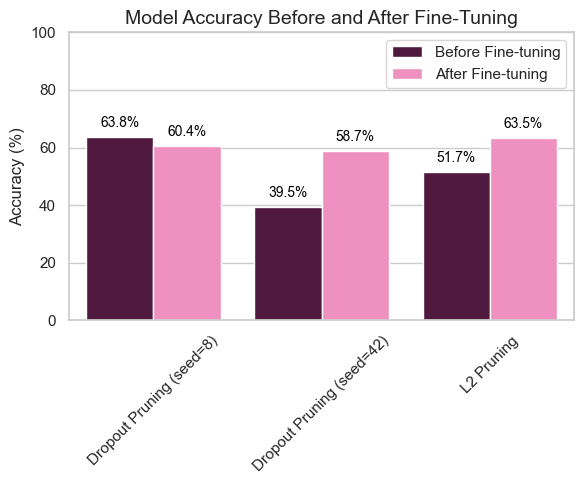

In [46]:
palette = ['#580F41', '#FF81C0']
sns.set(style="whitegrid")
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=df_fine_tuning,
    x='Method',
    y='Accuracy',
    hue='Stage',
    palette= palette
)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.title('Model Accuracy Before and After Fine-Tuning', fontsize=14)
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.ylabel('Accuracy (%)')
plt.xlabel('')
plt.legend(title='', loc='upper right')
plt.savefig("code_fotos/fine_tuned_with_seed.pdf", format='pdf')
plt.tight_layout()
plt.show()

# Experiment 2: Stability and Variability of Dropout-based Pruning 

In [50]:
dropout_rate = 0.5
results_for_seedrange = []
seed_pool = list(range(10))  

In [51]:
for seed in seed_pool:
    print(f"\n=== Pruning with fixed dropout_rate = {dropout_rate}, seed = {seed} ===")

    model = SimpleCNN().to(device)
    model.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))  

    pruned_model = prune_model_based_on_dropout(model, dropout_rate=dropout_rate, seed=seed)

    trainable_params = sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)

    pruned_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = pruned_model(inputs, seed=seed, dropout_p=0.0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    results_for_seedrange.append({
        'seed': seed,
        'dropout_rate': dropout_rate,
        'accuracy': accuracy,
        'trainable_params': trainable_params
    })

df_seed_range= pd.DataFrame(results_for_seedrange)
df_seed_range['sparsity_%'] = 100 * (1 - df_seed_range['trainable_params'] / df_seed_range['trainable_params'].max())



=== Pruning with fixed dropout_rate = 0.5, seed = 0 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 1 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 2 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 3 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 4 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 5 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 6 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 7 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 8 ===
Model pruned.

=== Pruning with fixed dropout_rate = 0.5, seed = 9 ===
Model pruned.


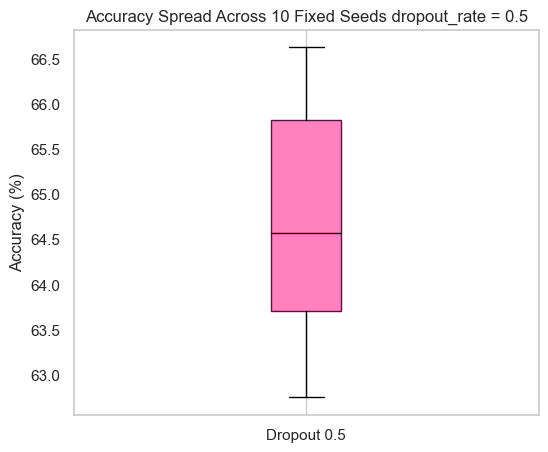

In [52]:
plt.figure(figsize=(6, 5))
plt.boxplot(df_seed_range['accuracy'], vert=True, patch_artist=True,
            boxprops=dict(facecolor=palette[1], color=palette[0]),
            medianprops=dict(color='black'))

plt.title('Accuracy Spread Across 10 Fixed Seeds dropout_rate = 0.5')
plt.ylabel('Accuracy (%)')
plt.xticks([1], ['Dropout 0.5'])
plt.savefig("code_fotos/box_plot_dropout_0.5.pdf", format='pdf')
plt.grid(axis='y')
plt.show()


## Full Range of Dropout Rates and Masks with Seed-controlled Training

In [53]:
all_results = []
seed_pool = list(range(10))  

In [54]:
for dropout_rate in dropout_rates:
    for seed in seed_pool:
        print(f"\n=== Pruning with dropout_rate = {dropout_rate}, seed = {seed} ===")
        
        exp_model = SimpleCNN().to(device)
        exp_model.load_state_dict(torch.load('initial_model_for_second_experiment.pth'))

        pruned_model = prune_model_based_on_dropout(exp_model, dropout_rate=dropout_rate, seed=seed)

        trainable_params = sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)

        pruned_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = pruned_model(inputs, seed=seed, dropout_p=0.0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        all_results.append({
            'dropout_rate': dropout_rate,
            'seed': seed,
            'accuracy': accuracy,
            'trainable_params': trainable_params
        })

df_all = pd.DataFrame(all_results)
df_all['sparsity_%'] = 100 * (1 - df_all['trainable_params'] / df_all['trainable_params'].max())


=== Pruning with dropout_rate = 0.0, seed = 0 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 1 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 2 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 3 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 4 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 5 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 6 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 7 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 8 ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 9 ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 0 ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 1 ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 2 ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 3 ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 4 ===
Model pruned.

=== Pruning with dropout

In [55]:
df_all

,dropout_rate,seed,accuracy,trainable_params,sparsity_%
0,0.0,0,63.821656,33930890,0.000000
1,0.0,1,63.821656,33930890,0.000000
2,0.0,2,63.821656,33930890,0.000000
3,0.0,3,63.821656,33930890,0.000000
4,0.0,4,63.821656,33930890,0.000000
...,...,...,...,...,...
95,0.9,5,16.382166,438635,98.707269
96,0.9,6,14.292994,405353,98.805357
97,0.9,7,11.821656,342126,98.991698
98,0.9,8,13.121019,329940,99.027612


/var/folders/9v/7tjlk73s3qqf9ng1jqg1ptsr0000gn/T/ipykernel_2724/957933681.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="dropout_rate", y="accuracy", data=df_all, palette="RdPu")


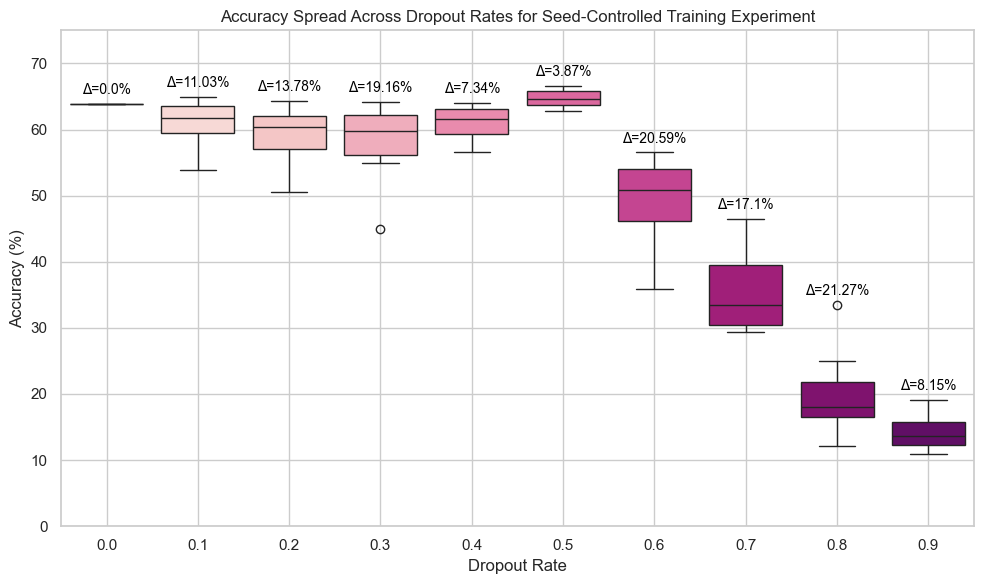

In [56]:
spread_values_with_seed = (
    df_all.groupby("dropout_rate")["accuracy"]
    .agg(["min", "max"])
    .reset_index()
)
spread_values_with_seed["spread"] = (spread_values_with_seed["max"] - spread_values_with_seed["min"]).round(2)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x="dropout_rate", y="accuracy", data=df_all, palette="RdPu")

for i, row in spread_values_with_seed.iterrows():
    x = i
    upper_whisker = row["max"]
    spread = row["spread"]
    ax.text(x, upper_whisker + 1.5, f"Δ={spread}%", ha='center', fontsize=10, color='black')

plt.title("Accuracy Spread Across Dropout Rates for Seed-Controlled Training Experiment")
plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 75)
plt.grid(True)
plt.savefig("code_fotos/box_plot_for_all_dropout_with_seed.pdf", format='pdf')
plt.tight_layout()
plt.show()

## Full Range of Dropout Rates and Masks with Uncontrolled Seed Training

In [57]:
all_results_seed_none = []

In [58]:
for dropout_rate in dropout_rates:
    for seed in seed_pool:
        print(f"\n=== Pruning with dropout_rate = {dropout_rate}, seed = {seed} for Initial Model ===")
        
        exp_model = SimpleCNN().to(device)
        exp_model.load_state_dict(torch.load('initial_trained_model.pth'))

        pruned_model = prune_model_based_on_dropout(exp_model, dropout_rate=dropout_rate, seed=seed)

        trainable_params = sum(p.numel() for p in pruned_model.parameters() if p.requires_grad)

        pruned_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = pruned_model(inputs, seed=seed, dropout_p=0.0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        all_results_seed_none.append({
            'dropout_rate': dropout_rate,
            'seed': seed,
            'accuracy': accuracy,
            'trainable_params': trainable_params
        })

df_seed_none = pd.DataFrame(all_results_seed_none)
df_seed_none['sparsity_%'] = 100 * (1 - df_seed_none['trainable_params'] / df_seed_none['trainable_params'].max())


=== Pruning with dropout_rate = 0.0, seed = 0 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 1 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 2 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 3 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 4 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 5 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 6 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 7 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 8 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.0, seed = 9 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 0 for Initial Model ===
Model pruned.

=== Pruning with dropout_rate = 0.1, seed = 1 for Initial Model ===
Model pruned.

===

In [59]:
df_seed_none

,dropout_rate,seed,accuracy,trainable_params,sparsity_%
0,0.0,0,67.694268,33930890,0.000000
1,0.0,1,67.694268,33930890,0.000000
2,0.0,2,67.694268,33930890,0.000000
3,0.0,3,67.694268,33930890,0.000000
4,0.0,4,67.694268,33930890,0.000000
...,...,...,...,...,...
95,0.9,5,19.108280,438635,98.707269
96,0.9,6,12.738854,405353,98.805357
97,0.9,7,14.242038,342126,98.991698
98,0.9,8,14.445860,329940,99.027612


/var/folders/9v/7tjlk73s3qqf9ng1jqg1ptsr0000gn/T/ipykernel_2724/1367984952.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="dropout_rate", y="accuracy", data=df_seed_none, palette="RdPu")


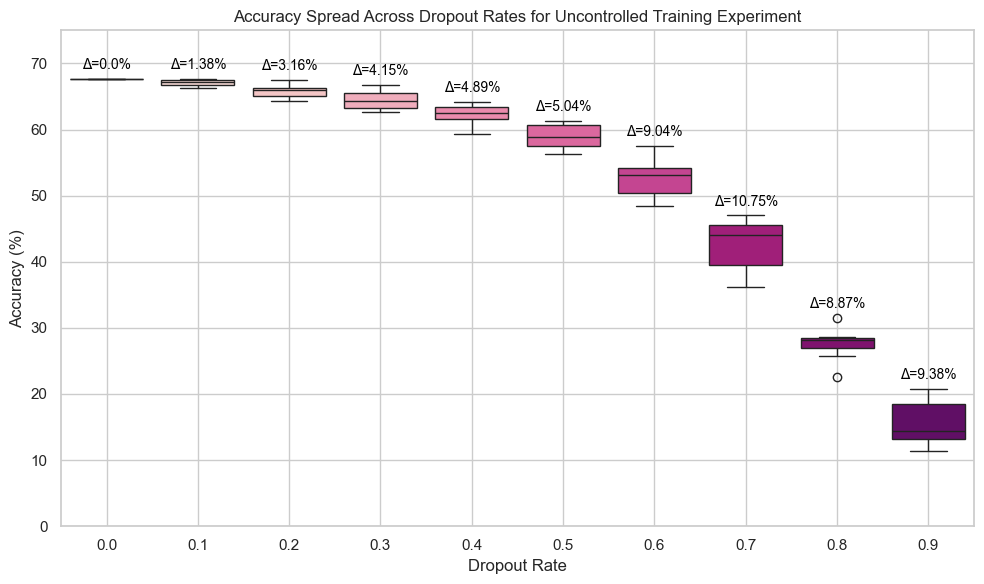

In [60]:
spread_values_without_seed = (
    df_seed_none.groupby("dropout_rate")["accuracy"]
    .agg(["min", "max"])
    .reset_index()
)
spread_values_without_seed["spread"] = (spread_values_without_seed["max"] - spread_values_without_seed["min"]).round(2)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x="dropout_rate", y="accuracy", data=df_seed_none, palette="RdPu")

for i, row in spread_values_without_seed.iterrows():
    x = i
    upper_whisker = row["max"]
    spread = row["spread"]
    ax.text(x, upper_whisker + 1.5, f"Δ={spread}%", ha='center', fontsize=10, color='black')

plt.title("Accuracy Spread Across Dropout Rates for Uncontrolled Training Experiment")
plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 75)
plt.grid(True)
plt.savefig("code_fotos/box_plot_for_all_dropout_without_seed.pdf", format='pdf')
plt.tight_layout()
plt.show()


In [61]:
df_seed_none[df_seed_none['dropout_rate'] == 0.8].sort_values(by='accuracy')

,dropout_rate,seed,accuracy,trainable_params,sparsity_%
80,0.8,0,22.573248,1267100,96.265645
81,0.8,1,25.808917,1590206,95.313397
84,0.8,4,26.853503,1273506,96.246765
88,0.8,8,27.541401,1320224,96.109079
85,0.8,5,27.898089,1501365,95.575227
87,0.8,7,28.331210,1043168,96.925610
82,0.8,2,28.407643,848333,97.499821
83,0.8,3,28.509554,1393191,95.894033
86,0.8,6,28.662420,1384589,95.919385
89,0.8,9,31.439490,1482049,95.632154


## All models created and used in this work are available at the following link:
https://www.kaggle.com/models/semenetsdaryna/dropout-for-neural-network-pruning